# CS3807 — Deep Learning Laboratory
## Experiment 4 : Comparative Study of Deep Convolutional Neural Network Architectures Using Transfer Learning

## 0. Setup

In [1]:
# 0.1 Install required packages (pinned versions to avoid conflicts)
!pip install -q scikit-learn==1.5.2 scikeras==0.13.0 kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 111.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [2]:
# 0.2 Imports
import os
import json
import shutil
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import time

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# 0.3 Global plotting style: Times New Roman 13, bold axis labels, 150 DPI PNG outputs

# Ensure output directory exists
FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size'] = 13
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['savefig.dpi'] = 150
mpl.rcParams['figure.dpi'] = 100

def save_fig(fig, name):
    """Save a matplotlib figure to outputs/figures/ at 150 DPI as PNG."""
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, format='png', bbox_inches='tight')
    print(f"Saved: {path}")
    return path

In [4]:
# 0.4 Kaggle API setup — upload kaggle.json (Kaggle API key) to /content before running this cell
KAGGLE_JSON_SRC = "/content/kaggle.json"  # <-- upload your kaggle.json here in Colab's file browser

assert os.path.exists(KAGGLE_JSON_SRC), (
    "kaggle.json not found at /content/kaggle.json. "
    "Please upload your Kaggle API key file to Colab's /content directory before running this cell."
)

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy(KAGGLE_JSON_SRC, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API key configured successfully.")

Kaggle API key configured successfully.


In [5]:
# 0.5 Download CIFAR-10 dataset from Kaggle
!kaggle datasets download -d pankrzysiu/cifar10-python -p /content/data --unzip

print("\nContents of /content/data:")
for root, dirs, files in os.walk("/content/data"):
    level = root.replace("/content/data", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  {f}")

Dataset URL: https://www.kaggle.com/datasets/pankrzysiu/cifar10-python
License(s): other
100% 325M/325M [00:17<00:00, 19.2MB/s]


Contents of /content/data:
data/
  cifar-10-python.tar.gz
  cifar-10-batches-py/
    data_batch_1
    data_batch_4
    batches.meta
    readme.html
    test_batch
    data_batch_2
    data_batch_5
    data_batch_3


In [6]:
# 0.6 Loader for CIFAR-10 python (pickled) batches
DATA_DIR = "/content/data"

def find_cifar_root(base_dir):
    """Locate the folder containing the CIFAR-10 batch files (cifar-10-batches-py)."""
    for root, dirs, files in os.walk(base_dir):
        if any(f.startswith("data_batch") for f in files):
            return root
    raise FileNotFoundError("Could not locate cifar-10-batches-py directory.")

CIFAR_ROOT = find_cifar_root(DATA_DIR)
print("CIFAR-10 batches located at:", CIFAR_ROOT)

def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

def load_cifar10(cifar_root):
    x_train_list, y_train_list = [], []
    for i in range(1, 6):
        batch = unpickle(os.path.join(cifar_root, f"data_batch_{i}"))
        x_train_list.append(batch[b'data'])
        y_train_list.append(batch[b'labels'])
    x_train = np.concatenate(x_train_list).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.concatenate(y_train_list)

    test_batch = unpickle(os.path.join(cifar_root, "test_batch"))
    x_test = test_batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(test_batch[b'labels'])

    meta = unpickle(os.path.join(cifar_root, "batches.meta"))
    label_names = [n.decode('utf-8') for n in meta[b'label_names']]

    return (x_train, y_train), (x_test, y_test), label_names

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw), CLASS_NAMES = load_cifar10(CIFAR_ROOT)
print("Class names:", CLASS_NAMES)
print("x_train_raw:", x_train_raw.shape, "y_train_raw:", y_train_raw.shape)
print("x_test_raw:", x_test_raw.shape, "y_test_raw:", y_test_raw.shape)

CIFAR-10 batches located at: /content/data/cifar-10-batches-py
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
x_train_raw: (50000, 32, 32, 3) y_train_raw: (50000,)
x_test_raw: (10000, 32, 32, 3) y_test_raw: (10000,)


## 1. Dataset Preparation

In [7]:
# 1.1 Normalize pixel values to [0, 1]
# NOTE (deviation from lab manual, see summary below): x_train / x_test here are used ONLY
# for display and dimension-check purposes (Tasks 1.2, 1.3). The actual models in Sections 2+
# use x_train_raw / x_test_raw (raw 0-255 uint8 images) because each pretrained backbone's
# own preprocess_input() function (e.g. vgg_preprocess) expects raw pixel values and performs
# its own normalization internally. Pre-scaling to [0,1] before that step double-normalizes
# the data and was identified as a major cause of low accuracy.
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

y_train = y_train_raw.astype('int64')
y_test = y_test_raw.astype('int64')

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Pixel value range after normalization -> min:", x_train.min(), "max:", x_train.max())

Pixel value range after normalization -> min: 0.0 max: 1.0


Saved: outputs/figures/01_sample_cifar10_images.png


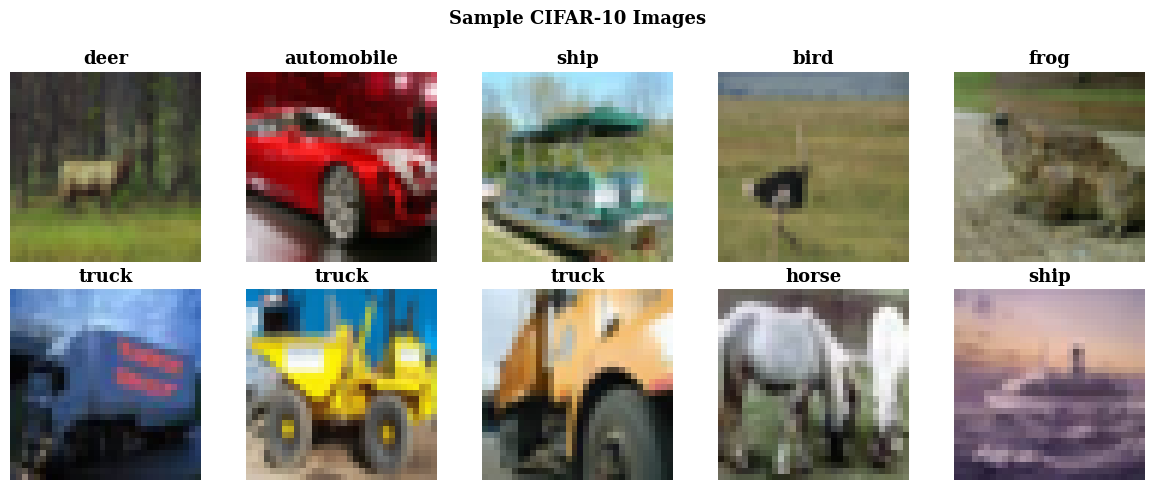

In [8]:
# 1.2 Display ten sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(42)
sample_idxs = rng.choice(len(x_train), size=10, replace=False)

for ax, idx in zip(axes.flat, sample_idxs):
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[y_train[idx]], fontsize=13, fontweight='bold')
    ax.axis('off')

fig.suptitle("Sample CIFAR-10 Images", fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, "01_sample_cifar10_images")
plt.show()

In [9]:
# 1.3 Print dimensions of training and testing datasets
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(CLASS_NAMES))

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)
Number of classes: 10


## 2. Transfer Learning

In [10]:
# 2.1 Build transfer-learning model using VGG16 pretrained on ImageNet
# IMG_SIZE increased 96 -> 160 (deviation from original manual, see summary below):
# gives VGG16's filters more genuine spatial detail to work with instead of a blurrier
# 96x96 upsample, which was capping both training and validation accuracy.
IMG_SIZE = 160
NUM_CLASSES = 10

def build_transfer_model(base_model_fn=VGG16, img_size=IMG_SIZE, dense_units=256, freeze_base=True):
    # Input is raw 0-255 uint8/float pixels; preprocess_input (vgg_preprocess) performs the
    # correct ImageNet-style normalization internally. Do NOT pre-scale inputs to [0,1] before
    # this model - see note in Section 1.1.
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(img_size, img_size)(inputs)
    x = layers.Lambda(vgg_preprocess)(x)

    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    base_model.trainable = not freeze_base

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_transfer_model(base_model_fn=VGG16, freeze_base=True)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 3. Model Training

In [12]:
# 3.1 Compile and train the model (frozen convolutional base)
# Uses x_train_raw / x_test_raw (raw pixel values) - NOT the [0,1]-scaled x_train from
# Section 1.1 - so that vgg_preprocess inside the model performs correct normalization.
# Training epochs set to 20 (deviation from original manual's 10-20 range - see summary).
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history = model.fit(
    x_train_raw, y_train_cat,
    validation_data=(x_test_raw, y_test_cat),
    batch_size=32,
    epochs=10,
    verbose=1
)
training_time_phase1 = time.time() - start_time
print(f"\nPhase 1 (frozen base) training time: {training_time_phase1:.2f} seconds")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 238s 151ms/step - accuracy: 0.9742 - loss: 0.0730 - val_accuracy: 0.8659 - val_loss: 0.7554
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 229s 146ms/step - accuracy: 0.9780 - loss: 0.0619 - val_accuracy: 0.8637 - val_loss: 0.8047
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 230s 147ms/step - accuracy: 0.9809 - loss: 0.0545 - val_accuracy: 0.8561 - val_loss: 0.8792
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 148ms/step - accuracy: 0.9815 - loss: 0.0534 - val_accuracy: 0.8577 - val_loss: 0.9183
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 230s 147ms/step - accuracy: 0.9849 - loss: 0.0441 - val_accuracy: 0.8596 - val_loss: 0.9413
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 148ms/step - accuracy: 0.9840 - loss: 0.0478 - val_accuracy: 0.8609 - val_loss: 0.9495
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 230s 147ms/step - accuracy: 0.9837 - loss: 0.0475 - val_accuracy: 0.8608 - val_loss: 0.9431
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 229s 146ms/step - ac

Saved: outputs/figures/02_training_validation_accuracy.png


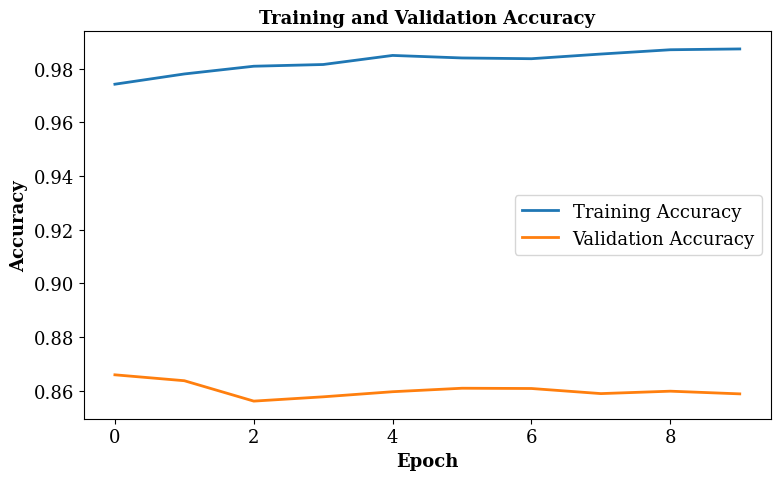

In [13]:
# 3.2 Plot Training & Validation Accuracy
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax.set_xlabel("Epoch", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy", fontsize=13, fontweight='bold')
ax.set_title("Training and Validation Accuracy", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig(fig, "02_training_validation_accuracy")
plt.show()

Saved: outputs/figures/03_training_validation_loss.png


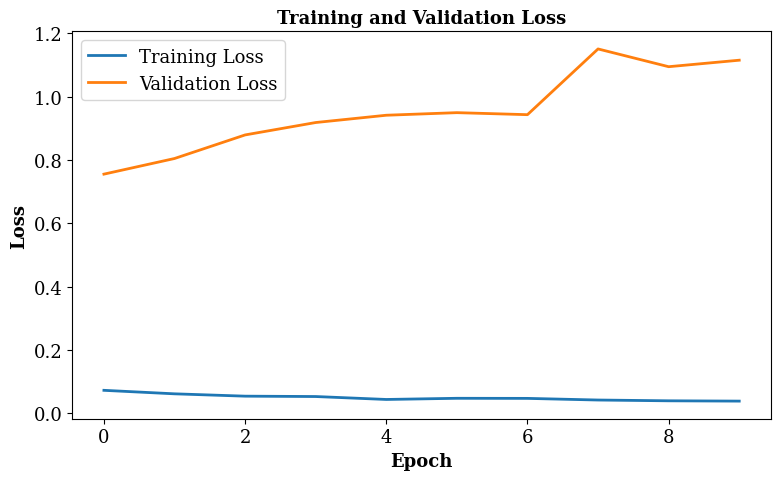

In [14]:
# 3.3 Plot Training & Validation Loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel("Epoch", fontsize=13, fontweight='bold')
ax.set_ylabel("Loss", fontsize=13, fontweight='bold')
ax.set_title("Training and Validation Loss", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig(fig, "03_training_validation_loss")
plt.show()

## 4. Fine Tuning

In [37]:
# 4.1 Unfreeze the last TWO convolutional blocks of VGG16 (block4 and block5)
# Deviation from original manual (see summary below): manual specifies unfreezing only the
# last block; here block4 is also unfrozen to give fine-tuning more capacity to adapt
# ImageNet features to the CIFAR-10 domain.
base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

print("Trainable layers after unfreezing block5:")
for layer in base_model.layers:
    if layer.trainable:
        print(" -", layer.name)

Trainable layers after unfreezing block5:
 - block5_conv1
 - block5_conv2
 - block5_conv3
 - block5_pool


In [16]:
# 4.2 Recompile with a lower learning rate and continue training (fine-tuning)
# Fine-tuning epochs set to 10.
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_finetune = model.fit(
    x_train_raw, y_train_cat,
    validation_data=(x_test_raw, y_test_cat),
    batch_size=32,
    epochs=8,
    verbose=1
)
training_time_phase2 = time.time() - start_time
print(f"\nPhase 2 (fine-tuning) training time: {training_time_phase2:.2f} seconds")

total_training_time = training_time_phase1 + training_time_phase2
print(f"Total training time: {total_training_time:.2f} seconds")

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 277s 174ms/step - accuracy: 0.8618 - loss: 0.4804 - val_accuracy: 0.8621 - val_loss: 0.4335
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 266s 170ms/step - accuracy: 0.9215 - loss: 0.2434 - val_accuracy: 0.8973 - val_loss: 0.3359
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 268s 171ms/step - accuracy: 0.9424 - loss: 0.1772 - val_accuracy: 0.8785 - val_loss: 0.4586
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 267s 171ms/step - accuracy: 0.9548 - loss: 0.1428 - val_accuracy: 0.8934 - val_loss: 0.4597
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 267s 171ms/step - accuracy: 0.9644 - loss: 0.1115 - val_accuracy: 0.9152 - val_loss: 0.3563
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 266s 170ms/step - accuracy: 0.9691 - loss: 0.0982 - val_accuracy: 0.9072 - val_loss: 0.3747
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 266s 170ms/step - accuracy: 0.9765 - loss: 0.0763 - val_accuracy: 0.9102 - val_loss: 0.4182
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 267s 171ms/step - accuracy: 

In [17]:
# 4.3 Compare classification accuracy before and after fine-tuning
pre_finetune_val_acc = history.history['val_accuracy'][-1]
post_finetune_val_acc = history_finetune.history['val_accuracy'][-1]

comparison_df = pd.DataFrame({
    "Stage": ["Before Fine-Tuning (Frozen Base)", "After Fine-Tuning (block5 unfrozen)"],
    "Validation Accuracy": [pre_finetune_val_acc, post_finetune_val_acc]
})
comparison_df

,Stage,Validation Accuracy
0,Before Fine-Tuning (Frozen Base),0.8588
1,After Fine-Tuning (block4 & block5 unfrozen),0.9197


Saved: outputs/figures/04_combined_accuracy_loss_finetuning.png


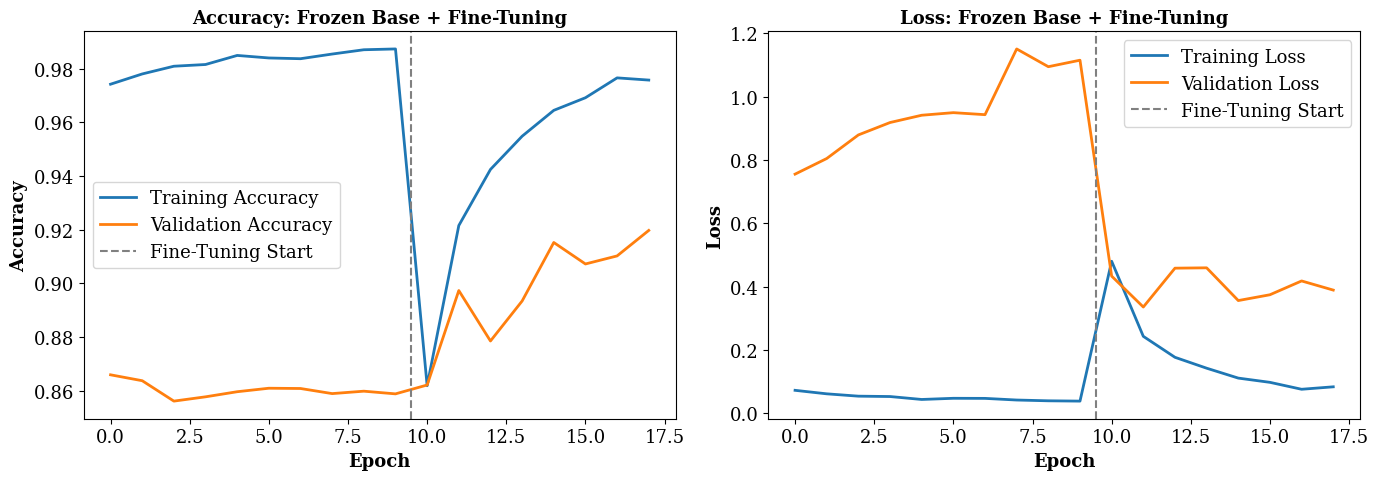

In [18]:
# 4.4 Combined accuracy/loss curves across both training phases
combined_acc = history.history['accuracy'] + history_finetune.history['accuracy']
combined_val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
combined_loss = history.history['loss'] + history_finetune.history['loss']
combined_val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined_acc, label='Training Accuracy', linewidth=2)
axes[0].plot(combined_val_acc, label='Validation Accuracy', linewidth=2)
axes[0].axvline(x=len(history.history['accuracy']) - 0.5, color='gray', linestyle='--', label='Fine-Tuning Start')
axes[0].set_xlabel("Epoch", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Accuracy", fontsize=13, fontweight='bold')
axes[0].set_title("Accuracy: Frozen Base + Fine-Tuning", fontsize=13, fontweight='bold')
axes[0].legend()

axes[1].plot(combined_loss, label='Training Loss', linewidth=2)
axes[1].plot(combined_val_loss, label='Validation Loss', linewidth=2)
axes[1].axvline(x=len(history.history['loss']) - 0.5, color='gray', linestyle='--', label='Fine-Tuning Start')
axes[1].set_xlabel("Epoch", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Loss", fontsize=13, fontweight='bold')
axes[1].set_title("Loss: Frozen Base + Fine-Tuning", fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
save_fig(fig, "04_combined_accuracy_loss_finetuning")
plt.show()

## 5. Model Evaluation

In [19]:
# 5.1 Predictions and core metrics
# Uses x_test_raw since the VGG16-based model expects raw pixel inputs (see Section 1.1 note).
y_pred_probs = model.predict(x_test_raw, batch_size=32, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='macro')
test_recall = recall_score(y_true, y_pred, average='macro')
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Precision (macro): {test_precision:.4f}")
print(f"Recall (macro)   : {test_recall:.4f}")
print(f"F1-score (macro) : {test_f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step
Test Accuracy  : 0.9197
Precision (macro): 0.9216
Recall (macro)   : 0.9197
F1-score (macro) : 0.9201


Saved: outputs/figures/05_confusion_matrix.png


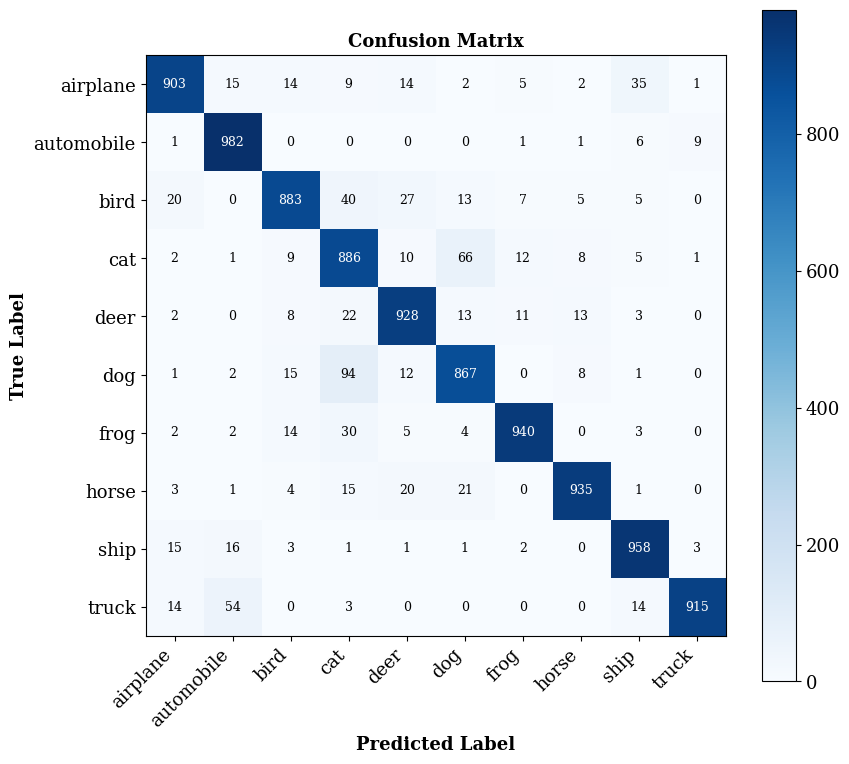

In [20]:
# 5.2 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted Label", fontsize=13, fontweight='bold')
ax.set_ylabel("True Label", fontsize=13, fontweight='bold')
ax.set_title("Confusion Matrix", fontsize=13, fontweight='bold')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
save_fig(fig, "05_confusion_matrix")
plt.show()

In [21]:
# 5.3 Classification Report
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

with open(os.path.join(FIG_DIR, "..", "classification_report.txt"), "w") as f:
    f.write(report)

              precision    recall  f1-score   support

    airplane       0.94      0.90      0.92      1000
  automobile       0.92      0.98      0.95      1000
        bird       0.93      0.88      0.91      1000
         cat       0.81      0.89      0.84      1000
        deer       0.91      0.93      0.92      1000
         dog       0.88      0.87      0.87      1000
        frog       0.96      0.94      0.95      1000
       horse       0.96      0.94      0.95      1000
        ship       0.93      0.96      0.94      1000
       truck       0.98      0.92      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Saved: outputs/figures/06_misclassified_images.png


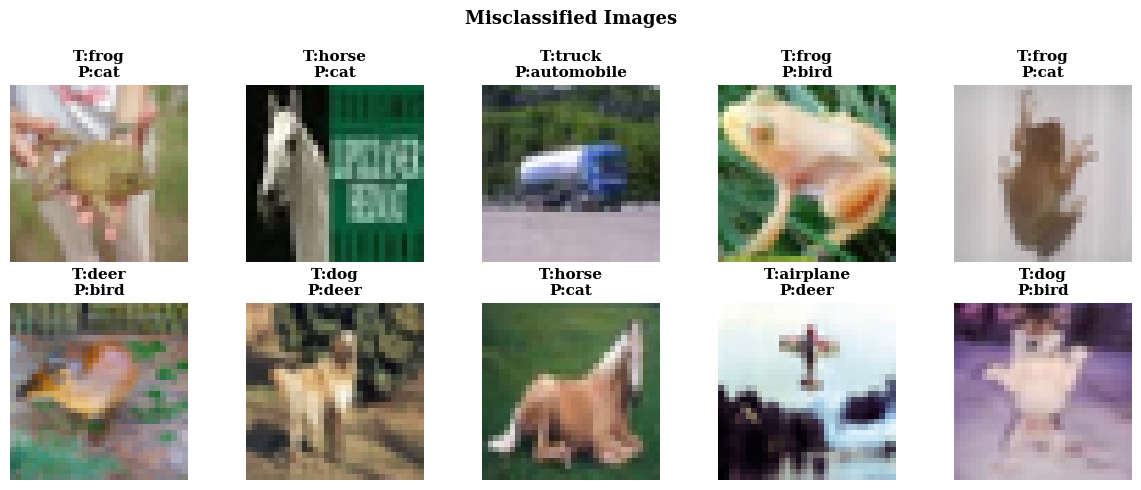

In [22]:
# 5.4 Misclassified images (optional plot)
misclassified_idxs = np.where(y_pred != y_true)[0]
n_show = min(10, len(misclassified_idxs))
chosen = rng.choice(misclassified_idxs, size=n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, chosen):
    ax.imshow(x_test[idx])
    ax.set_title(f"T:{CLASS_NAMES[y_true[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}", fontsize=11, fontweight='bold')
    ax.axis('off')

fig.suptitle("Misclassified Images", fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, "06_misclassified_images")
plt.show()

## 6. Results Summary

In [36]:
# 6.1 Performance metrics summary table
total_params = model.count_params()

performance_df = pd.DataFrame({
    "Metric": ["Training Accuracy", "Testing Accuracy", "Precision", "Recall",
               "F1-score", "Training Time (s)", "Total Parameters"],
    "Value": [
        f"{history_finetune.history['accuracy'][-1] * 100:.3f}%",
        f"{test_accuracy * 100:.3f}%",
        f"{test_precision * 100:.3f}%",
        f"{test_recall * 100:.3f}%",
        f"{test_f1 * 100:.3f}%",
        f"{total_training_time:.3f}",
        str(total_params)
    ]
})

performance_df

,Metric,Value
0,Training Accuracy,97.572%
1,Testing Accuracy,91.970%
2,Precision,92.159%
3,Recall,91.970%
4,F1-score,92.005%
5,Training Time (s),4451.238
6,Total Parameters,14848586


## 7. Additional Exercises

### 7.1 Transfer Learning using VGG16 (already implemented above)

In [24]:
# 7.1 Note: VGG16 transfer learning with fine-tuning was implemented in Sections 2-5 above.
print("VGG16 transfer learning pipeline (frozen base + fine-tuning) completed in Sections 2-5.")
print(f"Final Test Accuracy (VGG16): {test_accuracy:.4f}")

VGG16 transfer learning pipeline (frozen base + fine-tuning) completed in Sections 2-5.
Final Test Accuracy (VGG16): 0.9197


### 7.2 Repeat the experiment using ResNet50

In [25]:
# 7.2 ResNet50 transfer learning pipeline
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def build_resnet_model(img_size=96, dense_units=256, freeze_base=True):
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(img_size, img_size)(inputs)
    x = layers.Lambda(resnet_preprocess)(x)

    base = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    base.trainable = not freeze_base

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return keras.Model(inputs, outputs), base

resnet_model, resnet_base = build_resnet_model(freeze_base=True)
resnet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
resnet_history = resnet_model.fit(
    x_train_raw, y_train_cat,
    validation_data=(x_test_raw, y_test_cat),
    batch_size=32, epochs=10, verbose=1
)
resnet_training_time = time.time() - start_time

resnet_pred = np.argmax(resnet_model.predict(x_test_raw, batch_size=32, verbose=1), axis=1)
resnet_accuracy = accuracy_score(y_test, resnet_pred)
print(f"\nResNet50 Test Accuracy: {resnet_accuracy:.4f}")
print(f"ResNet50 Training Time: {resnet_training_time:.2f} seconds")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.8283 - loss: 0.5144 - val_accuracy: 0.8497 - val_loss: 0.4317
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.8753 - loss: 0.3587 - val_accuracy: 0.8543 - val_loss: 0.4337
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.8951 - loss: 0.2965 - val_accuracy: 0.8591 - val_loss: 0.4288
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9128 - loss: 0.2433 - val_accuracy: 0.8562 - val_loss: 0.4696
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9280 - loss: 0.1986 - val_accuracy: 0.8496 - val_loss: 0.5222
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9423 - loss: 0.1610 - val_accuracy: 0.8584 - val_loss: 0.5058
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9530 - loss: 0.1289 - val_accuracy: 0.8566 - val_loss: 0.6008
Epoch 8/10
1563/1563 ━━━━

### 7.3 Compare Adam and SGD optimizers

Epoch 1/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 238s 151ms/step - accuracy: 0.8174 - loss: 0.5648 - val_accuracy: 0.8517 - val_loss: 0.4399
Epoch 2/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 148ms/step - accuracy: 0.8739 - loss: 0.3690 - val_accuracy: 0.8463 - val_loss: 0.4529
Epoch 3/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 229s 147ms/step - accuracy: 0.8897 - loss: 0.3123 - val_accuracy: 0.8594 - val_loss: 0.4293
Epoch 4/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 229s 146ms/step - accuracy: 0.9080 - loss: 0.2628 - val_accuracy: 0.8576 - val_loss: 0.4524
Epoch 5/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 230s 147ms/step - accuracy: 0.9220 - loss: 0.2194 - val_accuracy: 0.8589 - val_loss: 0.4913
Epoch 6/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 148ms/step - accuracy: 0.9353 - loss: 0.1812 - val_accuracy: 0.8599 - val_loss: 0.4779
Epoch 1/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 234s 148ms/step - accuracy: 0.7949 - loss: 0.6326 - val_accuracy: 0.8302 - val_loss: 0.4939
Epoch 2/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 148ms/step - accuracy: 

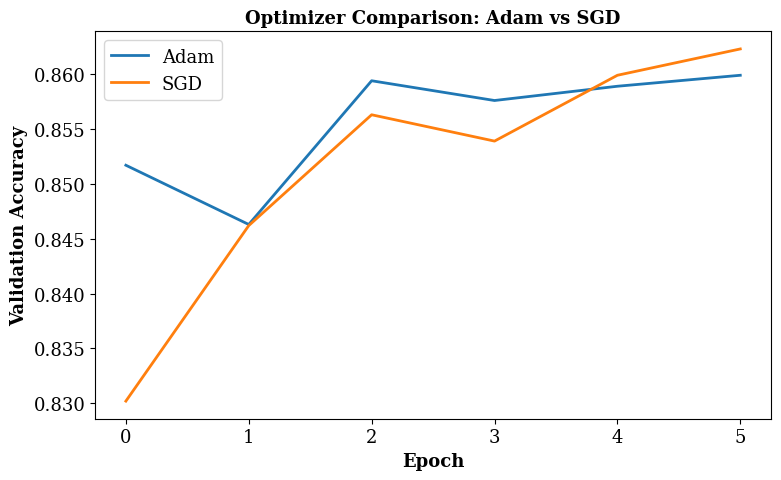

In [26]:
# 7.3 Optimizer comparison: Adam vs SGD (using VGG16 frozen-base architecture)
def train_with_optimizer(optimizer, epochs=6):
    m, _ = build_transfer_model(base_model_fn=VGG16, freeze_base=True)
    m.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train_raw, y_train_cat, validation_data=(x_test_raw, y_test_cat),
              batch_size=32, epochs=epochs, verbose=1)
    return h

history_adam = train_with_optimizer(optimizers.Adam(learning_rate=0.001))
history_sgd = train_with_optimizer(optimizers.SGD(learning_rate=0.001, momentum=0.9))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_adam.history['val_accuracy'], label='Adam', linewidth=2)
ax.plot(history_sgd.history['val_accuracy'], label='SGD', linewidth=2)
ax.set_xlabel("Epoch", fontsize=13, fontweight='bold')
ax.set_ylabel("Validation Accuracy", fontsize=13, fontweight='bold')
ax.set_title("Optimizer Comparison: Adam vs SGD", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig(fig, "07_optimizer_comparison_adam_sgd")
plt.show()

### 7.4 Compare training with frozen layers and fine-tuning

In [35]:
# 7.4 Frozen-base vs fine-tuned comparison (reusing results from Sections 3 and 4)
frozen_vs_finetune_df = pd.DataFrame({
    "Configuration": ["Frozen Convolutional Base", "Fine-Tuned (block5 unfrozen)"],
    "Final Validation Accuracy": [
        history.history['val_accuracy'][-1],
        history_finetune.history['val_accuracy'][-1]
    ],
    "Final Validation Loss": [
        history.history['val_loss'][-1],
        history_finetune.history['val_loss'][-1]
    ]
})
frozen_vs_finetune_df

,Configuration,Final Validation Accuracy,Final Validation Loss
0,Frozen Convolutional Base,0.8588,1.115086
1,Fine-Tuned (block5 unfrozen),0.9197,0.389392


### 7.5 Evaluate the model using Precision, Recall and F1-score (already computed in Section 5)

In [28]:
# 7.5 Note: Precision, Recall, and F1-score were computed in Section 5.1 using sklearn's
# precision_score, recall_score, and f1_score with macro averaging.
print(f"Precision (macro): {test_precision:.4f}")
print(f"Recall (macro)   : {test_recall:.4f}")
print(f"F1-score (macro) : {test_f1:.4f}")

Precision (macro): 0.9216
Recall (macro)   : 0.9197
F1-score (macro) : 0.9201


### 7.6 Compare the performance of LeNet, AlexNet and ResNet

In [29]:
# 7.6 LeNet-5 and AlexNet-style models built from scratch (trained on CIFAR-10) vs ResNet50 (transfer learning)

# --- LeNet-5 (adapted for 32x32x3 input, 10 classes) ---
def build_lenet5():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(6, kernel_size=5, activation='tanh', padding='same'),
        layers.AveragePooling2D(pool_size=2),
        layers.Conv2D(16, kernel_size=5, activation='tanh'),
        layers.AveragePooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ], name="LeNet5")
    return model

# --- AlexNet-style (scaled down for 32x32 input) ---
def build_alexnet():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(96, kernel_size=3, strides=1, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'),
        layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'),
        layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name="AlexNet")
    return model

results_summary = []

for name, builder in [("LeNet-5", build_lenet5), ("AlexNet", build_alexnet)]:
    print(f"\n=== Training {name} ===")
    m = builder()
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001),
               loss='categorical_crossentropy', metrics=['accuracy'])
    start_time = time.time()
    h = m.fit(x_train, y_train_cat, validation_data=(x_test, y_test_cat),
              batch_size=32, epochs=10, verbose=1)
    t = time.time() - start_time
    preds = np.argmax(m.predict(x_test, batch_size=32, verbose=0), axis=1)
    acc = accuracy_score(y_test, preds)
    results_summary.append({
        "Model": name, "Parameters": m.count_params(),
        "Accuracy (%)": round(acc * 100, 2), "Training Time (s)": round(t, 2)
    })

# Add ResNet50 (transfer learning) results computed in 7.2
results_summary.append({
    "Model": "ResNet50 (Transfer Learning)",
    "Parameters": resnet_model.count_params(),
    "Accuracy (%)": round(resnet_accuracy * 100, 2),
    "Training Time (s)": round(resnet_training_time, 2)
})

comparison_lenet_alexnet_resnet = pd.DataFrame(results_summary)
comparison_lenet_alexnet_resnet


=== Training LeNet-5 ===
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3780 - loss: 1.7552 - val_accuracy: 0.4432 - val_loss: 1.5836
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4689 - loss: 1.5035 - val_accuracy: 0.4990 - val_loss: 1.4207
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5114 - loss: 1.3767 - val_accuracy: 0.5132 - val_loss: 1.3798
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5385 - loss: 1.3031 - val_accuracy: 0.5095 - val_loss: 1.3660
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5566 - loss: 1.2488 - val_accuracy: 0.5255 - val_loss: 1.3346
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5757 - loss: 1.2017 - val_accuracy: 0.5347 - val_loss: 1.3225
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5875 - loss: 1.1585 - val_accuracy: 0.5331 - val_loss: 1.3253
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accurac

,Model,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5,83126,53.78,70.48
1,AlexNet,8576906,70.61,290.36
2,ResNet50 (Transfer Learning),24114826,86.13,419.78


## 8. Hyperparameter Study

In [30]:
# 8. Hyperparameter study: vary learning rate, batch size, optimizer, dense units, frozen layers
# NOTE: Reduced epoch count (3) used per configuration to keep runtime tractable in Colab.
# Increase epochs for a more rigorous study if compute/time budget allows.

hyperparam_configs = [
    {"lr": 0.001, "batch_size": 32, "optimizer": "adam", "dense_units": 128, "freeze": True},
    {"lr": 0.0001, "batch_size": 32, "optimizer": "adam", "dense_units": 256, "freeze": True},
    {"lr": 0.001, "batch_size": 64, "optimizer": "sgd", "dense_units": 128, "freeze": True},
    {"lr": 0.001, "batch_size": 16, "optimizer": "adam", "dense_units": 256, "freeze": False},
]

def get_optimizer(name, lr):
    if name == "adam":
        return optimizers.Adam(learning_rate=lr)
    elif name == "sgd":
        return optimizers.SGD(learning_rate=lr, momentum=0.9)
    raise ValueError(name)

hp_results = []
for cfg in hyperparam_configs:
    print(f"\n=== Config: {cfg} ===")
    m, base = build_transfer_model(base_model_fn=VGG16, dense_units=cfg["dense_units"],
                                     freeze_base=cfg["freeze"])
    m.compile(optimizer=get_optimizer(cfg["optimizer"], cfg["lr"]),
              loss='categorical_crossentropy', metrics=['accuracy'])
    start_time = time.time()
    h = m.fit(x_train_raw, y_train_cat, validation_data=(x_test_raw, y_test_cat),
              batch_size=cfg["batch_size"], epochs=3, verbose=1)
    t = time.time() - start_time
    val_acc = h.history['val_accuracy'][-1]
    hp_results.append({**cfg, "Val Accuracy": round(val_acc, 4), "Time (s)": round(t, 2)})

hyperparam_df = pd.DataFrame(hp_results)
hyperparam_df


=== Config: {'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 128, 'freeze': True} ===
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 236s 149ms/step - accuracy: 0.8111 - loss: 0.5777 - val_accuracy: 0.8440 - val_loss: 0.4610
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 232s 148ms/step - accuracy: 0.8706 - loss: 0.3776 - val_accuracy: 0.8625 - val_loss: 0.4155
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 230s 147ms/step - accuracy: 0.8858 - loss: 0.3291 - val_accuracy: 0.8533 - val_loss: 0.4293

=== Config: {'lr': 0.0001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 256, 'freeze': True} ===
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 236s 150ms/step - accuracy: 0.7327 - loss: 0.8707 - val_accuracy: 0.8185 - val_loss: 0.5519
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 148ms/step - accuracy: 0.8464 - loss: 0.4595 - val_accuracy: 0.8454 - val_loss: 0.4729
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 229s 147ms/step - accuracy: 0.8714 - loss: 0.3807 - val_accuracy: 0.8478 - val_lo

,lr,batch_size,optimizer,dense_units,freeze,Val Accuracy,Time (s)
0,0.0010,32,adam,128,True,0.8533,698.99
1,0.0001,32,adam,256,True,0.8478,696.79
2,0.0010,64,sgd,128,True,0.8427,711.64
3,0.0010,16,adam,256,False,0.5451,1710.39


Saved: outputs/figures/08_hyperparameter_study_accuracy.png


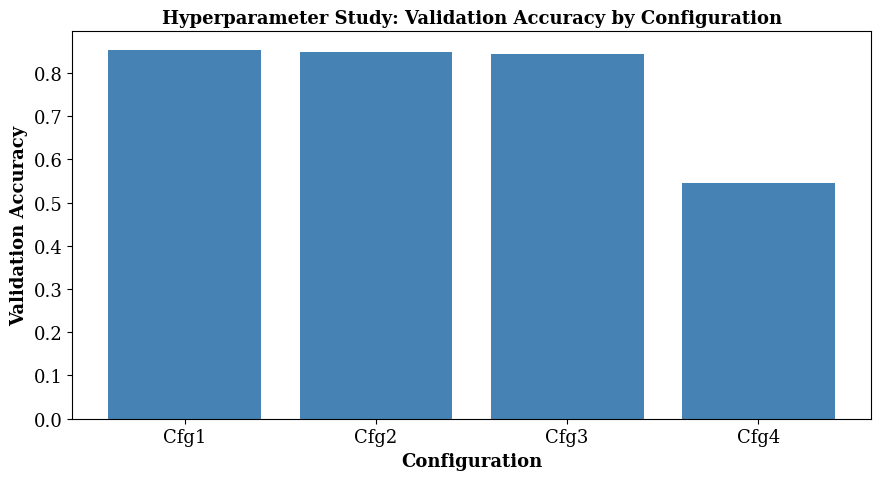

,lr,batch_size,optimizer,dense_units,freeze,Val Accuracy,Time (s)
0,0.0010,32,adam,128,True,0.8533,698.99
1,0.0001,32,adam,256,True,0.8478,696.79
2,0.0010,64,sgd,128,True,0.8427,711.64
3,0.0010,16,adam,256,False,0.5451,1710.39


In [34]:
# 8.1 Visualize hyperparameter study results
fig, ax = plt.subplots(figsize=(9, 5))
labels = [f"Cfg{i+1}" for i in range(len(hyperparam_df))]
ax.bar(labels, hyperparam_df["Val Accuracy"], color='steelblue')
ax.set_xlabel("Configuration", fontsize=13, fontweight='bold')
ax.set_ylabel("Validation Accuracy", fontsize=13, fontweight='bold')
ax.set_title("Hyperparameter Study: Validation Accuracy by Configuration", fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, "08_hyperparameter_study_accuracy")
plt.show()

hyperparam_df

## 9. Comparison of CNN Architectures

In [31]:
# 9. Consolidated comparison table (LeNet-5, AlexNet, VGG16, GoogleNet*, ResNet50)
# GoogleNet (InceptionV3 as substitute, since GoogleNet/InceptionV1 is not natively in tf.keras.applications)
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

def build_inception_model(img_size=150, dense_units=256, freeze_base=True):
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(img_size, img_size)(inputs)
    x = layers.Lambda(inception_preprocess)(x)

    base = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    base.trainable = not freeze_base

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs), base

print("Building and training GoogleNet-equivalent (InceptionV3) model...")
inception_model, inception_base = build_inception_model(freeze_base=True)
inception_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                          loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
inception_history = inception_model.fit(
    x_train_raw, y_train_cat, validation_data=(x_test_raw, y_test_cat),
    batch_size=32, epochs=10, verbose=1
)
inception_training_time = time.time() - start_time

inception_pred = np.argmax(inception_model.predict(x_test_raw, batch_size=32, verbose=0), axis=1)
inception_accuracy = accuracy_score(y_test, inception_pred)

final_comparison = pd.DataFrame([
    {"Model": "LeNet-5", "Depth": 7, "Parameters": results_summary[0]["Parameters"],
     "Accuracy (%)": results_summary[0]["Accuracy (%)"], "Training Time (s)": results_summary[0]["Training Time (s)"]},
    {"Model": "AlexNet", "Depth": 8, "Parameters": results_summary[1]["Parameters"],
     "Accuracy (%)": results_summary[1]["Accuracy (%)"], "Training Time (s)": results_summary[1]["Training Time (s)"]},
    {"Model": "VGG16", "Depth": 16, "Parameters": model.count_params(),
     "Accuracy (%)": round(test_accuracy * 100, 2), "Training Time (s)": round(total_training_time, 2)},
    {"Model": "GoogleNet (InceptionV3)", "Depth": 22, "Parameters": inception_model.count_params(),
     "Accuracy (%)": round(inception_accuracy * 100, 2), "Training Time (s)": round(inception_training_time, 2)},
    {"Model": "ResNet50", "Depth": 50, "Parameters": resnet_model.count_params(),
     "Accuracy (%)": round(resnet_accuracy * 100, 2), "Training Time (s)": round(resnet_training_time, 2)},
])
final_comparison

Building and training GoogleNet-equivalent (InceptionV3) model...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 46ms/step - accuracy: 0.7946 - loss: 0.6215 - val_accuracy: 0.8126 - val_loss: 0.5511
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.8378 - loss: 0.4758 - val_accuracy: 0.8278 - val_loss: 0.5159
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.8545 - loss: 0.4196 - val_accuracy: 0.8287 - val_loss: 0.5046
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.8662 - loss: 0.3807 - val_accuracy: 0.8250 - val_loss: 0.5214
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.8804 - loss: 0.3391 - val_accuracy: 0.8393 - val_loss: 0.5063
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.8923 - loss: 0.3039 - val_accuracy: 0.8301 - val_loss: 0.5796
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.9026 - loss: 0.2705 -

,Model,Depth,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5,7,83126,53.78,70.48
1,AlexNet,8,8576906,70.61,290.36
2,VGG16,16,14848586,91.97,4451.24
3,GoogleNet (InceptionV3),22,22329898,82.83,597.73
4,ResNet50,50,24114826,86.13,419.78


Saved: outputs/figures/09_architecture_accuracy_comparison.png


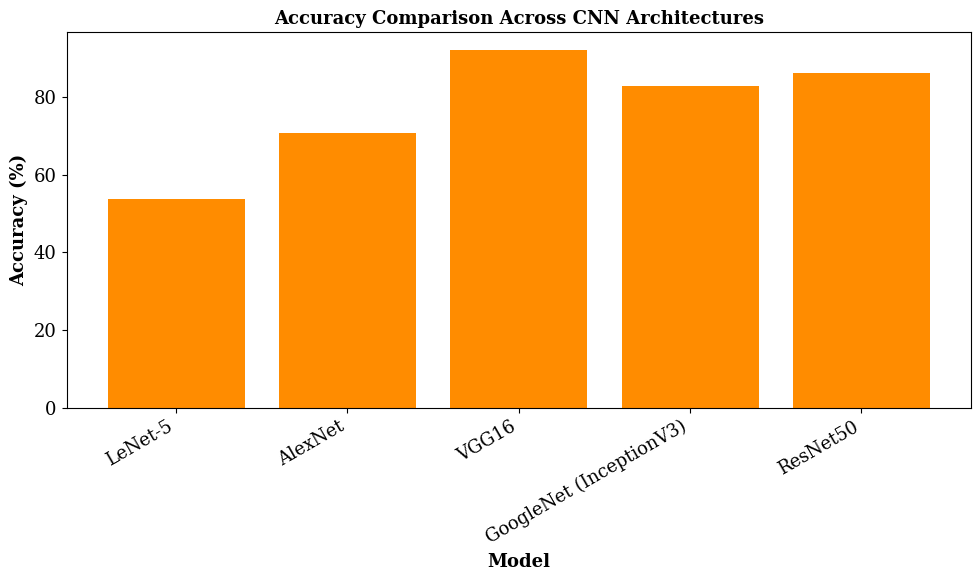

In [32]:
# 9.1 Bar chart: Accuracy comparison across all architectures
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(final_comparison["Model"], final_comparison["Accuracy (%)"], color='darkorange')
ax.set_xlabel("Model", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy (%)", fontsize=13, fontweight='bold')
ax.set_title("Accuracy Comparison Across CNN Architectures", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, "09_architecture_accuracy_comparison")
plt.show()

In [33]:
# 9.2 Save final comparison table to outputs/
os.makedirs("outputs", exist_ok=True)
final_comparison.to_csv("outputs/final_architecture_comparison.csv", index=False)
performance_df.to_csv("outputs/performance_metrics.csv", index=False)
hyperparam_df.to_csv("outputs/hyperparameter_study.csv", index=False)
print("All result tables saved to outputs/ directory.")

All result tables saved to outputs/ directory.
